In [1]:
import kagglehub
bhavikjikadara_dog_and_cat_classification_dataset_path = kagglehub.dataset_download('bhavikjikadara/dog-and-cat-classification-dataset')

print('Data source import complete.')

c:\Users\prash\anaconda3\envs\gpt2_finetune\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


In [2]:
print(bhavikjikadara_dog_and_cat_classification_dataset_path)

C:\Users\prash\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1


In [3]:
import os
dataset_root = r'C:\Users\prash\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1'
print(os.listdir(dataset_root))

['PetImages']


In [4]:
import os
import shutil
from sklearn.model_selection import train_test_split

# ✅ Updated dataset path (from kagglehub)
input_dir = r'C:\Users\prash\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1\PetImages'

# ✅ Output directory for split data
output_base = '/content/split_data'  # Colab writable area
train_dir = os.path.join(output_base, 'train')
test_dir = os.path.join(output_base, 'test')

# Create output directories
for subdir in ['train/cats', 'train/dogs', 'test/cats', 'test/dogs']:
    os.makedirs(os.path.join(output_base, subdir), exist_ok=True)

# Gather image paths and labels
image_paths = []
labels = []

for label in ['Cat', 'Dog']:
    full_path = os.path.join(input_dir, label)
    for fname in os.listdir(full_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            fpath = os.path.join(full_path, fname)
            # Skip broken files
            try:
                with open(fpath, 'rb') as f:
                    f.read()
                image_paths.append(fpath)
                labels.append('cats' if label == 'Cat' else 'dogs')
            except:
                continue

# Split dataset
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# Copy files to train/test folders
def copy_images(paths, labels, dest_dir):
    for path, label in zip(paths, labels):
        try:
            shutil.copy(path, os.path.join(dest_dir, label, os.path.basename(path)))
        except:
            continue

copy_images(train_paths, train_labels, train_dir)
copy_images(test_paths, test_labels, test_dir)

print("✅ Split complete.")
print(f"Train set: {len(train_paths)} images")
print(f"Test set:  {len(test_paths)} images")

✅ Split complete.
Train set: 19998 images
Test set:  5000 images


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Define AlexNet model from scratch (same as before)
class AlexNet(nn.Module):
    def __init__(self, num_classes=2):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # Two additional Conv layers added here:
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(128 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 1000),
            nn.ReLU(inplace=True),
            nn.Linear(1000, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# 2. Data preprocessing & augmentation
train_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean/std (can also compute own)
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 3. Dataset paths
train_dir = '/content/split_data/train'
test_dir = '/content/split_data/test'

# 4. Create datasets and dataloaders
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")

Using device: cuda
Number of training images: 19998
Number of testing images: 5000


In [6]:

# 5. Initialize model, loss, optimizer
model = AlexNet(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 6. Training function
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# 7. Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds

# 8. Train and evaluate the model for multiple epochs
num_epochs = 10

In [7]:

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_labels, val_preds = evaluate(model, test_loader, criterion, device)
    
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.4f}")
    print(f"  Val loss:   {val_loss:.4f} | Val accuracy:   {val_acc:.4f}")

# 9. Print detailed classification report
print("\nClassification Report on Test Set:")
print(classification_report(val_labels, val_preds, target_names=train_dataset.classes))

Epoch 1/10:
  Train loss: 0.6697 | Train accuracy: 0.5756
  Val loss:   0.6429 | Val accuracy:   0.6418
Epoch 2/10:
  Train loss: 0.6034 | Train accuracy: 0.6711
  Val loss:   0.5265 | Val accuracy:   0.7448
Epoch 3/10:
  Train loss: 0.4952 | Train accuracy: 0.7555
  Val loss:   0.4289 | Val accuracy:   0.7980
Epoch 4/10:
  Train loss: 0.4018 | Train accuracy: 0.8169
  Val loss:   0.3588 | Val accuracy:   0.8450
Epoch 5/10:
  Train loss: 0.3329 | Train accuracy: 0.8521
  Val loss:   0.3816 | Val accuracy:   0.8446
Epoch 6/10:
  Train loss: 0.2924 | Train accuracy: 0.8747
  Val loss:   0.2793 | Val accuracy:   0.8840
Epoch 7/10:
  Train loss: 0.2538 | Train accuracy: 0.8915
  Val loss:   0.2691 | Val accuracy:   0.8832
Epoch 8/10:
  Train loss: 0.2295 | Train accuracy: 0.9038
  Val loss:   0.2793 | Val accuracy:   0.8790
Epoch 9/10:
  Train loss: 0.2087 | Train accuracy: 0.9107
  Val loss:   0.2416 | Val accuracy:   0.9000
Epoch 10/10:
  Train loss: 0.1858 | Train accuracy: 0.9250
  Val

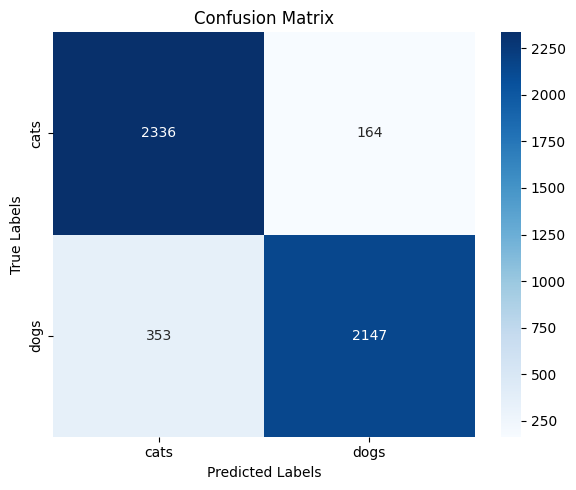

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 10. Generate and plot confusion matrix
cm = confusion_matrix(val_labels, val_preds)
class_names = train_dataset.classes

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [11]:
# Save the trained model weights
os.makedirs("Models", exist_ok=True)
save_path = "Models/alexnet_extended_catdog.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to Models/alexnet_extended_catdog.pth


In [13]:
# Loading
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize and load model
model = AlexNet(num_classes=2).to(device)
model.load_state_dict(torch.load("Models/alexnet_extended_catdog.pth", map_location=device))

C:\Users\prash\AppData\Local\Temp\ipykernel_28308\1101635045.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("Models/alexnet_extended_ca

<All keys matched successfully>